<a href="https://colab.research.google.com/github/derekwang8/undergrad_ml_assignments/blob/main/04_assignment_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1.
   The penalty discourages very large coefficients. Large coefficients usually mean the model is bending itself to match noise in the training sample, so the penalty pushes the fit toward a simpler model that should generalize better.

2.  
   As the penalty gets larger, the model becomes simpler. That usually increases bias, because the model is less flexible, but it lowers variance, because the fitted coefficients move around less from sample to sample. By changing the penalty, we move along the bias-variance trade-off.

3.
   Ridge uses an L2 penalty, so it shrinks coefficients continuously toward zero but usually does not make them exactly zero. LASSO uses an L1 penalty, so it can both shrink coefficients and set some of them exactly to zero. Ridge is better when many predictors have small effects; LASSO is useful when we think only a smaller subset of predictors really matters.

4.
   We usually standardize predictors to have mean 0 and standard deviation 1 before regularization. Otherwise, variables measured on bigger numeric scales would receive a different effective penalty just because of their units.

5.
   It is usually chosen by cross-validation. We fit the model over a grid of candidate values and pick the one with the lowest cross-validated prediction error.

6.
   No. The cross-validated MSE is meant to measure prediction error on held-out data, so we evaluate the usual prediction loss only. The penalty is part of training the model, not part of the out-of-sample prediction error.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [3]:
import io
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from IPython.display import display, Markdown

plt.style.use("seaborn-v0_8-whitegrid")

def clean_df(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    unnamed = [c for c in df.columns if c.lower().startswith("unnamed")]
    if unnamed:
        df = df.drop(columns=unnamed)
    if "H1" in df.columns:
        h1 = pd.to_numeric(df["H1"], errors="coerce")
        if h1.notna().all():
            df = df.drop(columns=["H1"])
    return df

def compare_coefficients(feature_names, ols_coef, lasso_coef, tol=1e-10):
    out = pd.DataFrame({
        "feature": feature_names,
        "OLS": ols_coef,
        "LASSO": lasso_coef
    })
    out["abs_OLS"] = out["OLS"].abs()
    out["abs_LASSO"] = out["LASSO"].abs()
    out["magnitude_increased"] = out["abs_LASSO"] > out["abs_OLS"] + tol
    out["sign_changed"] = np.sign(out["OLS"]) != np.sign(out["LASSO"])
    out["selected_by_lasso"] = out["LASSO"].abs() > tol
    return out.sort_values("abs_LASSO", ascending=False)

def print_markdown(text):
    display(Markdown(text))

In [4]:
cars = pd.read_csv("/content/cars_hw.csv")
cars["Make_Year"] = pd.to_numeric(cars["Make_Year"], errors="coerce")
cars["Mileage_Run"] = pd.to_numeric(cars["Mileage_Run"], errors="coerce")
cars["Price"] = pd.to_numeric(cars["Price"], errors="coerce")

current_year = pd.Timestamp.today().year
cars["Age"] = current_year - cars["Make_Year"]

q2_df = cars[["Mileage_Run", "Age", "Price"]].dropna().copy()

poly2 = PolynomialFeatures(degree=3, include_bias=False)
X2_poly = poly2.fit_transform(q2_df[["Mileage_Run", "Age"]])
feature_names_q2 = poly2.get_feature_names_out(["Mileage_Run", "Age"])

scaler2 = StandardScaler()
X2 = scaler2.fit_transform(X2_poly)
y2 = q2_df["Price"].to_numpy()

ols2 = LinearRegression()
ols2.fit(X2, y2)

alphas2 = np.logspace(1, 3, 20)
lasso2 = LassoCV(alphas=alphas2, cv=20, max_iter=200000, random_state=42)
lasso2.fit(X2, y2)

coef_table_q2 = compare_coefficients(feature_names_q2, ols2.coef_, lasso2.coef_)
interaction_name_q2 = "Mileage_Run Age"
interaction_sign_q2 = np.sign(coef_table_q2.set_index("feature").loc[interaction_name_q2, "OLS"])

print_markdown(f"""
## Q2. Results

**Interaction sign in the linear regression:** `{interaction_name_q2}` has a **{"positive" if interaction_sign_q2 > 0 else "negative" if interaction_sign_q2 < 0 else "zero"}** coefficient.

**Best alpha from 20-fold CV:** `{lasso2.alpha_:,.4f}`

**Features selected by LASSO:** `{int(coef_table_q2["selected_by_lasso"].sum())}` out of `{len(coef_table_q2)}`

**Proportion set to zero:** `{(1 - coef_table_q2["selected_by_lasso"].mean()):.2%}`
""")

display(coef_table_q2[["feature", "OLS", "LASSO", "magnitude_increased", "sign_changed", "selected_by_lasso"]])



## Q2. Results

**Interaction sign in the linear regression:** `Mileage_Run Age` has a **negative** coefficient.

**Best alpha from 20-fold CV:** `88.5867`

**Features selected by LASSO:** `8` out of `9`

**Proportion set to zero:** `11.11%`


,feature,OLS,LASSO,magnitude_increased,sign_changed,selected_by_lasso
3,Mileage_Run Age,-1.671212e+06,-1.322419e+06,False,False,True
0,Mileage_Run,9.117748e+05,7.790762e+05,False,False,True
7,Mileage_Run Age^2,7.167816e+05,5.415432e+05,False,False,True
6,Mileage_Run^2 Age,3.388195e+05,2.715062e+05,False,False,True
2,Mileage_Run^2,-2.072926e+05,-2.015634e+05,False,False,True
1,Age,-2.481722e+05,-1.339534e+05,False,False,True
5,Mileage_Run^3,-6.514490e+04,-4.240952e+04,False,False,True
8,Age^3,-2.100379e+05,1.374220e+04,False,True,True
4,Age^2,3.505507e+05,0.000000e+00,False,True,False


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 274133304629.5, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 358372690458.125, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 477939687941.75, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective di

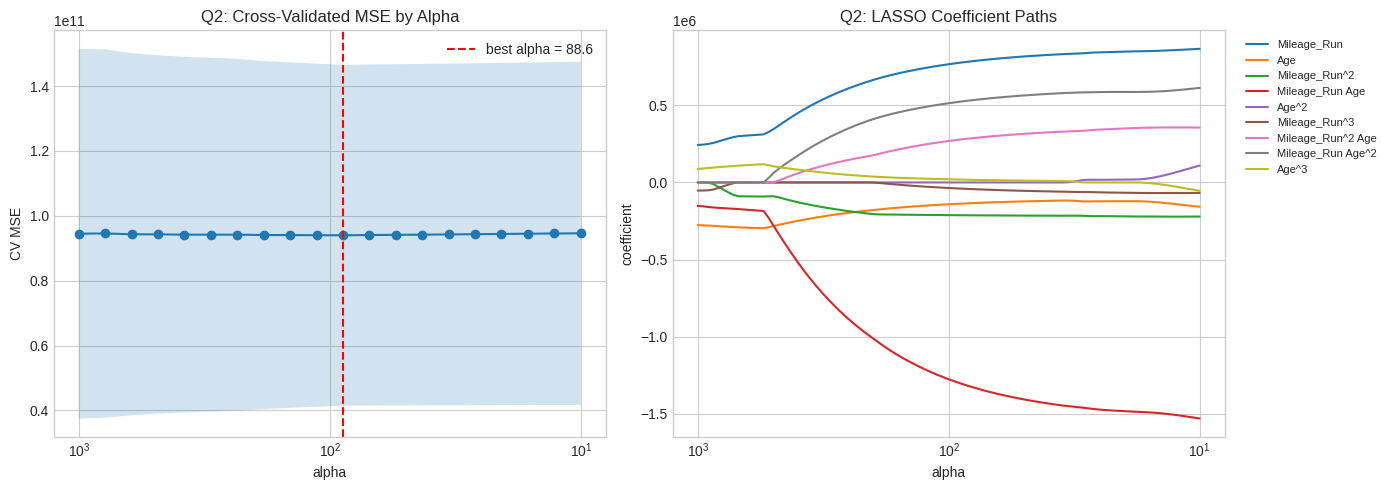


### Q2 interpretation

**Selected features:** ['Mileage_Run Age', 'Mileage_Run', 'Mileage_Run Age^2', 'Mileage_Run^2 Age', 'Mileage_Run^2', 'Age', 'Mileage_Run^3', 'Age^3']

**Any coefficients increase in magnitude from OLS to LASSO?**  
No, all retained coefficients shrink or stay essentially the same.

**Any coefficients change sign?**  
['Age^3', 'Age^2']

A short interpretation you can use: LASSO keeps the terms with the strongest predictive contribution and shrinks weak terms to zero, producing a simpler model with lower variance than the unrestricted polynomial regression.


In [5]:
mean_mse_q2 = lasso2.mse_path_.mean(axis=1)
std_mse_q2 = lasso2.mse_path_.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(lasso2.alphas_, mean_mse_q2, marker="o")
axes[0].fill_between(lasso2.alphas_, mean_mse_q2 - std_mse_q2, mean_mse_q2 + std_mse_q2, alpha=0.2)
axes[0].axvline(lasso2.alpha_, color="red", linestyle="--", label=f"best alpha = {lasso2.alpha_:.3g}")
axes[0].invert_xaxis()
axes[0].set_title("Q2: Cross-Validated MSE by Alpha")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("CV MSE")
axes[0].legend()

alphas_path_q2 = np.logspace(1, 3, 100)
alphas_path_q2, coefs_path_q2, _ = lasso_path(X2, y2, alphas=alphas_path_q2)

for i, name in enumerate(feature_names_q2):
    axes[1].semilogx(alphas_path_q2, coefs_path_q2[i], label=name)
axes[1].invert_xaxis()
axes[1].set_title("Q2: LASSO Coefficient Paths")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("coefficient")

if len(feature_names_q2) <= 10:
    axes[1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

increased_q2 = coef_table_q2.loc[coef_table_q2["magnitude_increased"], "feature"].tolist()
sign_changed_q2 = coef_table_q2.loc[coef_table_q2["sign_changed"], "feature"].tolist()
selected_q2 = coef_table_q2.loc[coef_table_q2["selected_by_lasso"], "feature"].tolist()

print_markdown(f"""
### Q2 interpretation

**Selected features:** {selected_q2 if selected_q2 else "None"}

**Any coefficients increase in magnitude from OLS to LASSO?**
{increased_q2 if increased_q2 else "No, all retained coefficients shrink or stay essentially the same."}

**Any coefficients change sign?**
{sign_changed_q2 if sign_changed_q2 else "No sign changes."}

A short interpretation you can use: LASSO keeps the terms with the strongest predictive contribution and shrinks weak terms to zero, producing a simpler model with lower variance than the unrestricted polynomial regression.
""")

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [8]:
heart = pd.read_csv("/content/heart_failure_clinical_records_dataset.csv")

target_candidates = ["DEATH_EVENT", "death_event", "y"]
target_col = next((c for c in target_candidates if c in heart.columns), None)
if target_col is None:
    raise ValueError(f"Could not find target column. Available columns: {list(heart.columns)}")

continuous_cols = ["age", "ejection_fraction", "serum_creatinine"]
dummy_cols = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]

missing_cont = [c for c in continuous_cols if c not in heart.columns]
missing_dummy = [c for c in dummy_cols if c not in heart.columns]
if missing_cont or missing_dummy:
    raise ValueError(
        f"Missing columns. Continuous missing: {missing_cont}; dummy missing: {missing_dummy}. "
        f"Available columns: {list(heart.columns)}"
    )

use_cols = continuous_cols + dummy_cols + [target_col]
heart = heart[use_cols].dropna().copy()

for c in use_cols:
    heart[c] = pd.to_numeric(heart[c], errors="coerce")
heart = heart.dropna().copy()

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X3_cont_poly = poly_cont.fit_transform(heart[continuous_cols])
cont_names = poly_cont.get_feature_names_out(continuous_cols)

scaler3 = StandardScaler()
X3_cont = scaler3.fit_transform(X3_cont_poly)

poly_dummy = PolynomialFeatures(degree=4, interaction_only=True, include_bias=False)
X3_dummy = poly_dummy.fit_transform(heart[dummy_cols])
dummy_names = poly_dummy.get_feature_names_out(dummy_cols)

X3 = np.hstack([X3_cont, X3_dummy])
feature_names_q3 = np.concatenate([cont_names, dummy_names])
y3 = heart[target_col].to_numpy()

ols3 = LinearRegression()
ols3.fit(X3, y3)

alphas3 = np.logspace(-5, 5, 30)
lasso3 = LassoCV(alphas=alphas3, cv=20, max_iter=300000, random_state=42)
lasso3.fit(X3, y3)

coef_table_q3 = compare_coefficients(feature_names_q3, ols3.coef_, lasso3.coef_)

print_markdown(f"""
## Q3. Results

**Best alpha from 20-fold CV:** `{lasso3.alpha_:,.6f}`

**Features selected by LASSO:** `{int(coef_table_q3["selected_by_lasso"].sum())}` out of `{len(coef_table_q3)}`

**Proportion set to zero:** `{(1 - coef_table_q3["selected_by_lasso"].mean()):.2%}`
""")

display(coef_table_q3[["feature", "OLS", "LASSO", "magnitude_increased", "sign_changed", "selected_by_lasso"]].head(25))



## Q3. Results

**Best alpha from 20-fold CV:** `0.005736`

**Features selected by LASSO:** `12` out of `34`

**Proportion set to zero:** `64.71%`


,feature,OLS,LASSO,magnitude_increased,sign_changed,selected_by_lasso
1,ejection_fraction,-2.062277,-0.329656,False,False,True
15,ejection_fraction^3,-1.245337,0.204822,False,True,True
9,age^3,1.963124,0.117992,False,False,True
2,serum_creatinine,-0.757092,0.116875,False,True,True
26,diabetes high_blood_pressure,0.212543,0.053968,False,False,True
18,serum_creatinine^3,-0.049181,-0.043266,False,False,True
16,ejection_fraction^2 serum_creatinine,-1.151378,0.032801,False,True,True
28,high_blood_pressure smoking,0.121481,0.017805,False,False,True
19,anaemia,-0.015590,0.014178,False,True,True
21,high_blood_pressure,-0.041251,0.013608,False,True,True


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.01772027176857449, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.032936844317262626, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.19049568701262132, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681

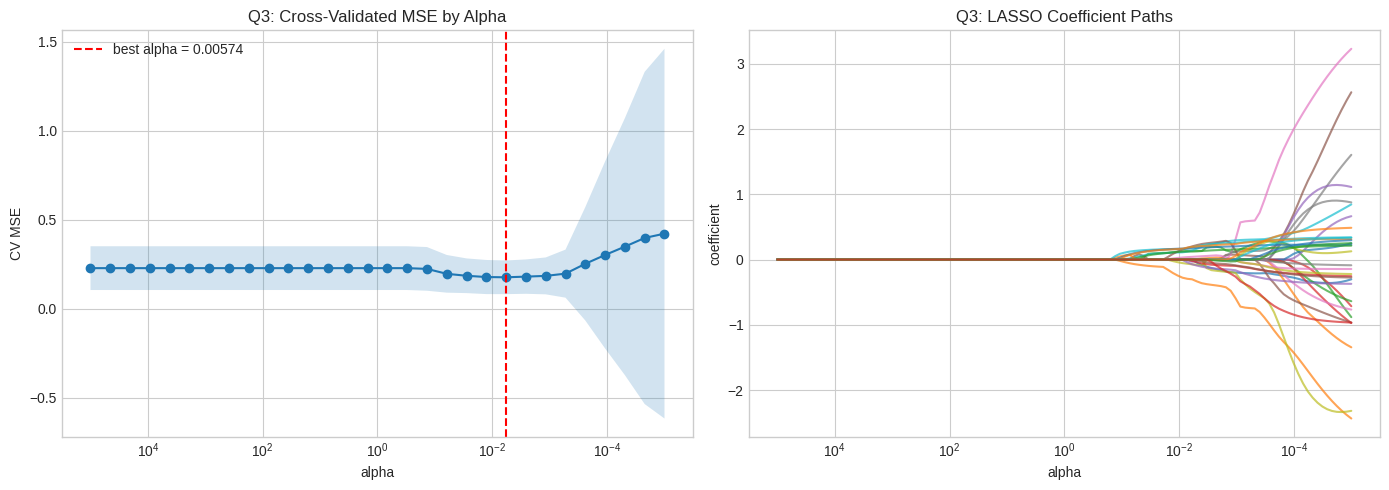


### Q3 interpretation

**Counterintuitive sign patterns in OLS:** inspect the OLS table, especially where a main effect has one sign but some higher-order or interaction terms involving the same variable have the opposite sign. This is not unusual in polynomial models because the marginal effect depends on the values of the other terms.

**Why can that happen?**  
Once powers and interactions are included, a single coefficient no longer tells the whole story. A negative main effect can be offset by a positive squared term or interaction term, so the net relationship can still be sensible.

**Selected features by LASSO:** ['ejection_fraction', 'ejection_fraction^3', 'age^3', 'serum_creatinine', 'diabetes high_blood_pressure', 'serum_creatinine^3', 'ejection_fraction^2 serum_creatinine', 'high_blood_pressure smoking', 'anaemia', 'high_blood_pressure', 'diabetes smoking', 'diabetes']

**Coefficients with larger magnitude under LASSO:** None

**Coefficients that change sign:** ['ejection_fraction^3', 'serum_creatinine', 'ejection_fraction^2 serum_creatinine', 'anaemia', 'high_blood_pressure', 'diabetes', 'age', 'serum_creatinine^2', 'age serum_creatinine', 'ejection_fraction^2', 'age ejection_fraction', 'age^2', 'ejection_fraction serum_creatinine^2', 'age serum_creatinine^2', 'age ejection_fraction^2', 'age ejection_fraction serum_creatinine', 'age^2 serum_creatinine', 'age^2 ejection_fraction', 'ejection_fraction serum_creatinine', 'smoking', 'anaemia smoking', 'anaemia high_blood_pressure', 'anaemia diabetes', 'anaemia diabetes high_blood_pressure', 'anaemia diabetes smoking', 'anaemia high_blood_pressure smoking', 'diabetes high_blood_pressure smoking', 'anaemia diabetes high_blood_pressure smoking']

**Which signs usually make more sense?**  
The LASSO signs are often easier to interpret because regularization removes unstable, high-variance terms. From the bias-variance perspective, LASSO accepts a little more bias in exchange for much lower variance, which often improves out-of-sample behavior and makes the model less noisy.


Top 10 OLS coefficients by absolute value:


,feature,OLS
3,age^2,-3.717758
6,ejection_fraction^2,3.352956
8,serum_creatinine^2,-2.640240
7,ejection_fraction serum_creatinine,2.569764
1,ejection_fraction,-2.062277
9,age^3,1.963124
5,age serum_creatinine,1.707056
13,age ejection_fraction serum_creatinine,-1.626996
0,age,1.619432
14,age serum_creatinine^2,1.444075


Top 10 LASSO coefficients by absolute value:


,feature,LASSO
1,ejection_fraction,-0.329656
15,ejection_fraction^3,0.204822
9,age^3,0.117992
2,serum_creatinine,0.116875
26,diabetes high_blood_pressure,0.053968
18,serum_creatinine^3,-0.043266
16,ejection_fraction^2 serum_creatinine,0.032801
28,high_blood_pressure smoking,0.017805
19,anaemia,0.014178
21,high_blood_pressure,0.013608


In [7]:
mean_mse_q3 = lasso3.mse_path_.mean(axis=1)
std_mse_q3 = lasso3.mse_path_.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(lasso3.alphas_, mean_mse_q3, marker="o")
axes[0].fill_between(lasso3.alphas_, mean_mse_q3 - std_mse_q3, mean_mse_q3 + std_mse_q3, alpha=0.2)
axes[0].axvline(lasso3.alpha_, color="red", linestyle="--", label=f"best alpha = {lasso3.alpha_:.3g}")
axes[0].invert_xaxis()
axes[0].set_title("Q3: Cross-Validated MSE by Alpha")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("CV MSE")
axes[0].legend()

alphas_path_q3 = np.logspace(-5, 5, 120)
alphas_path_q3, coefs_path_q3, _ = lasso_path(X3, y3, alphas=alphas_path_q3)

for i in range(coefs_path_q3.shape[0]):
    axes[1].semilogx(alphas_path_q3, coefs_path_q3[i], alpha=0.7)
axes[1].invert_xaxis()
axes[1].set_title("Q3: LASSO Coefficient Paths")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("coefficient")

plt.tight_layout()
plt.show()

selected_q3 = coef_table_q3.loc[coef_table_q3["selected_by_lasso"], "feature"].tolist()
increased_q3 = coef_table_q3.loc[coef_table_q3["magnitude_increased"], "feature"].tolist()
sign_changed_q3 = coef_table_q3.loc[coef_table_q3["sign_changed"], "feature"].tolist()

top_ols = coef_table_q3.reindex(coef_table_q3["OLS"].abs().sort_values(ascending=False).index).head(10)
top_lasso = coef_table_q3.reindex(coef_table_q3["LASSO"].abs().sort_values(ascending=False).index).head(10)

print_markdown(f"""
### Q3 interpretation

**Counterintuitive sign patterns in OLS:** inspect the OLS table, especially where a main effect has one sign but some higher-order or interaction terms involving the same variable have the opposite sign. This is not unusual in polynomial models because the marginal effect depends on the values of the other terms.

**Why can that happen?**
Once powers and interactions are included, a single coefficient no longer tells the whole story. A negative main effect can be offset by a positive squared term or interaction term, so the net relationship can still be sensible.

**Selected features by LASSO:** {selected_q3 if selected_q3 else "None"}

**Coefficients with larger magnitude under LASSO:** {increased_q3 if increased_q3 else "None"}

**Coefficients that change sign:** {sign_changed_q3 if sign_changed_q3 else "None"}

**Which signs usually make more sense?**
The LASSO signs are often easier to interpret because regularization removes unstable, high-variance terms. From the bias-variance perspective, LASSO accepts a little more bias in exchange for much lower variance, which often improves out-of-sample behavior and makes the model less noisy.
""")

print("Top 10 OLS coefficients by absolute value:")
display(top_ols[["feature", "OLS"]])

print("Top 10 LASSO coefficients by absolute value:")
display(top_lasso[["feature", "LASSO"]])


**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

## Q4. Regularization with One Explanatory Variable

We are working with the mean-centered model

$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$

where

$$
\tilde{y}_i = y_i - \bar{y}, \qquad \tilde{x}_i = x_i - \bar{x}.
$$

Because the variables are centered, we know

$$
\sum_{i=1}^n \tilde{y}_i = 0
\qquad \text{and} \qquad
\sum_{i=1}^n \tilde{x}_i = 0.
$$

### 1.

For ridge regression, we add the penalty $+\alpha b_1^2$ to the mean squared error. The objective function is

$$
J(b_0,b_1)
=
\frac{1}{n}\sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2
+
\alpha b_1^2.
$$

### 2.

Take derivatives with respect to $b_0$ and $b_1$.

#### Derivative with respect to $b_0$

$$
\frac{\partial J}{\partial b_0}
=
-\frac{2}{n}\sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i).
$$

Set equal to zero:

$$
-\frac{2}{n}\sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)=0.
$$

Using $\sum \tilde{y}_i = 0$ and $\sum \tilde{x}_i = 0$, this becomes

$$
-\frac{2}{n}(0 - nb_0 - b_1 \cdot 0)=0
\quad \Rightarrow \quad
b_0 = 0.
$$

#### Derivative with respect to $b_1$

$$
\frac{\partial J}{\partial b_1}
=
-\frac{2}{n}\sum_{i=1}^n \tilde{x}_i(\tilde{y}_i - b_0 - b_1 \tilde{x}_i)
+ 2\alpha b_1.
$$

Set equal to zero:

$$
-\frac{2}{n}\sum_{i=1}^n \tilde{x}_i(\tilde{y}_i - b_0 - b_1 \tilde{x}_i)
+ 2\alpha b_1 = 0.
$$

Substitute $b_0 = 0$:

$$
-\frac{2}{n}\sum_{i=1}^n \tilde{x}_i \tilde{y}_i
+
\frac{2}{n}b_1 \sum_{i=1}^n \tilde{x}_i^2
+
2\alpha b_1
=0.
$$

Rearranging gives

$$
b_1
\left(
\frac{1}{n}\sum_{i=1}^n \tilde{x}_i^2 + \alpha
\right)
=
\frac{1}{n}\sum_{i=1}^n \tilde{x}_i \tilde{y}_i.
$$

So the ridge solution is

$$
\hat{b}_1
=
\frac{\frac{1}{n}\sum_{i=1}^n \tilde{x}_i \tilde{y}_i}
{\frac{1}{n}\sum_{i=1}^n \tilde{x}_i^2 + \alpha}.
$$

and

$$
\hat{b}_0 = 0.
$$

### 3.

As $\alpha$ increases, the denominator of $\hat{b}_1$ gets larger, so the slope coefficient gets smaller in magnitude. In other words, ridge regression shrinks the slope toward zero. The larger the penalty, the more aggressive the shrinkage.

### 4.

With LASSO, the objective becomes

$$
J(b_0,b_1)
=
\frac{1}{n}\sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2
+
\alpha |b_1|.
$$

The main challenge is that $|b_1|$ is **not differentiable at $b_1=0$**, so we cannot use the usual derivative there. Instead, we have to use the idea of a **subgradient**.

Conceptually, LASSO behaves differently from ridge because it can set coefficients **exactly equal to zero**. If the relationship between $\tilde{x}$ and $\tilde{y}$ is weak enough, then the improvement in fit from using a nonzero slope is not worth paying the penalty, so the optimal choice is

$$
\hat{b}_1 = 0.
$$

So for LASSO, the key insight is:

- if the signal is strong, the slope is shrunk toward zero but remains nonzero;
- if the signal is weak relative to the penalty, the optimal slope is exactly zero.

That exact-zero behavior is what makes LASSO useful for variable selection.
